# 03 (v2) — Anchor sensitivity for the v2 CSV

Mirrors `03_exploration.ipynb`'s anchor-sensitivity sweep, with the v2 CSV (2026-05-20).

**Scope:** anchor sensitivity only. We're skipping the Fenix-vs-ALL-MOBILE gap-decomposition panel — that finding from v1 03 already established Fenix-only as the right validation target. The v2 CSV's growth shape differs from v1's (peak then decline vs monotonic growth), so the optimal anchor is worth re-checking.

For each candidate anchor we compute the lift series as `total_paid_dau(t) − total_paid_dau(anchor)`, clipped to 0 pre-anchor, then take the 28d MA and compare to the empirical Fenix Android gap MA over the post-launch non-Easter window.


In [1]:
# [setup]
from pathlib import Path

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

APRIL_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-04/'
    'mobile_cps0.02_thresh32_recent13_clip0.6/'
    'mozaic_daily_forecast.2026-04-01.gm-D.raw.parquet'
)
JUNE_FORECAST_PATH = Path(
    '/Users/brendanwells/work/mozaic-daily/data-official/2026-06/'
    'mobile_cps0.02_thresh32_recent13_clip0.6_cap426/'
    'mozaic_daily_forecast.2026-05-17.gm-D.raw.parquet'
)
SOURCE_CSV = Path('data/paid_dau_weekly_forecast.v2_model.20260520.csv')

CAMPAIGN_LAUNCH = pd.Timestamp('2026-04-06')
LAST_HISTORICAL_DATE = pd.Timestamp('2026-05-20')
PARQUET_START = pd.Timestamp('2026-02-01')
PARQUET_END = pd.Timestamp('2026-12-31')
MA_WINDOW = 28

EASTER_MASK_DATES = pd.DatetimeIndex(sorted(set(
    [pd.Timestamp('2026-04-05') + pd.Timedelta(days=d) for d in range(-2, 3)] +
    [pd.Timestamp('2026-04-18') + pd.Timedelta(days=d) for d in range(-2, 3)]
)))


def _load_forecast(path):
    df = pd.read_parquet(path)
    df['target_date'] = pd.to_datetime(df['target_date'])
    return df


def _aggregate(df, country, app_name, data_type_filter=None):
    rollup = df[(df['data_source'] == 'glean_mobile')
                & (df['country'] == country)
                & (df['app_name'] == app_name)
                & (df['segment'] == '{}')].copy()
    if data_type_filter is not None:
        rollup = rollup[rollup['data_type'] == data_type_filter]
    return rollup.set_index('target_date').sort_index()['dau']


april = _load_forecast(APRIL_FORECAST_PATH)
june = _load_forecast(JUNE_FORECAST_PATH)

# Read v2 CSV directly (no clean parquet for v2)
weekly_raw = pd.read_csv(SOURCE_CSV, thousands=',')
weekly_raw['week'] = pd.to_datetime(weekly_raw['week'])
weekly = (weekly_raw[['week', 'total_paid_dau']]
          .rename(columns={'week': 'week_starting'})
          .sort_values('week_starting')
          .reset_index(drop=True))
assert (weekly['week_starting'].dt.dayofweek == 0).all()

print(f'April forecast: {len(april):,} rows')
print(f'June forecast:  {len(june):,} rows')
print(f'Weekly CSV:     {len(weekly)} rows  ({weekly["week_starting"].min().date()} → {weekly["week_starting"].max().date()})')


April forecast: 199,232 rows
June forecast:  199,232 rows
Weekly CSV:     52 rows  (2026-01-05 → 2026-12-28)


In [2]:
# [anchor-sensitivity-setup]
# Build daily paid_dau series from v2 CSV, then for each candidate anchor produce
# a lift series and compare to Fenix gap MA on the post-launch non-Easter window.

weekly_indexed = weekly.set_index('week_starting')['total_paid_dau'].astype('float64')
daily_index = pd.date_range(weekly_indexed.index.min(), PARQUET_END, freq='D')
daily_paid = weekly_indexed.reindex(daily_index).interpolate(method='linear', limit_area='inside').ffill()
print(f'Daily paid DAU (v2): {daily_paid.index.min().date()} → {daily_paid.index.max().date()}, '
      f'{len(daily_paid)} days, NaN={daily_paid.isna().sum()}')

april_fenix = _aggregate(april, country='ALL', app_name='fenix_android')
actuals_fenix = _aggregate(june, country='ALL', app_name='fenix_android', data_type_filter='training')
fenix_gap_index = april_fenix.index.intersection(actuals_fenix.index)
fenix_gap_daily = actuals_fenix.reindex(fenix_gap_index) - april_fenix.reindex(fenix_gap_index)
fenix_gap_ma = fenix_gap_daily.rolling(MA_WINDOW, min_periods=14).mean()

post_ix = pd.date_range(CAMPAIGN_LAUNCH, LAST_HISTORICAL_DATE, freq='D').difference(EASTER_MASK_DATES)
print(f'\nFenix gap MA post-launch non-Easter mean (validation target): '
      f'{fenix_gap_ma.reindex(post_ix).mean():>+12,.0f}')


def build_lift_series(anchor_date):
    """Lift = daily_paid − daily_paid(anchor), pre-anchor clipped to 0."""
    anchor_value = float(daily_paid.loc[anchor_date])
    lift_raw = daily_paid - anchor_value
    full_ix = pd.date_range(PARQUET_START, PARQUET_END, freq='D')
    lift_daily = lift_raw.reindex(full_ix, fill_value=0.0)
    lift_daily = lift_daily.where(lift_daily.index >= anchor_date, 0.0)
    lift_ma = lift_daily.rolling(MA_WINDOW, min_periods=14).mean()
    return anchor_value, lift_daily, lift_ma


candidate_anchors = [
    pd.Timestamp('2026-04-06'),  # campaign launch week
    pd.Timestamp('2026-04-01'),  # mid-anchor-week
    pd.Timestamp('2026-03-30'),  # one week before launch — current v2 default
    pd.Timestamp('2026-03-16'),  # three weeks before
    pd.Timestamp('2026-02-23'),  # six weeks before (v1's residual minimum)
    pd.Timestamp('2026-02-01'),  # PARQUET_START
]
print(f'\nCandidate anchors:')
for a in candidate_anchors:
    print(f'  {a.date()}  daily_paid = {float(daily_paid.loc[a]):>10,.0f}')


Daily paid DAU (v2): 2026-01-05 → 2026-12-31, 361 days, NaN=0

Fenix gap MA post-launch non-Easter mean (validation target):     +218,144

Candidate anchors:
  2026-04-06  daily_paid =  1,053,915
  2026-04-01  daily_paid =  1,029,344
  2026-03-30  daily_paid =  1,019,515
  2026-03-16  daily_paid =    980,950
  2026-02-23  daily_paid =    941,212
  2026-02-01  daily_paid =    903,163


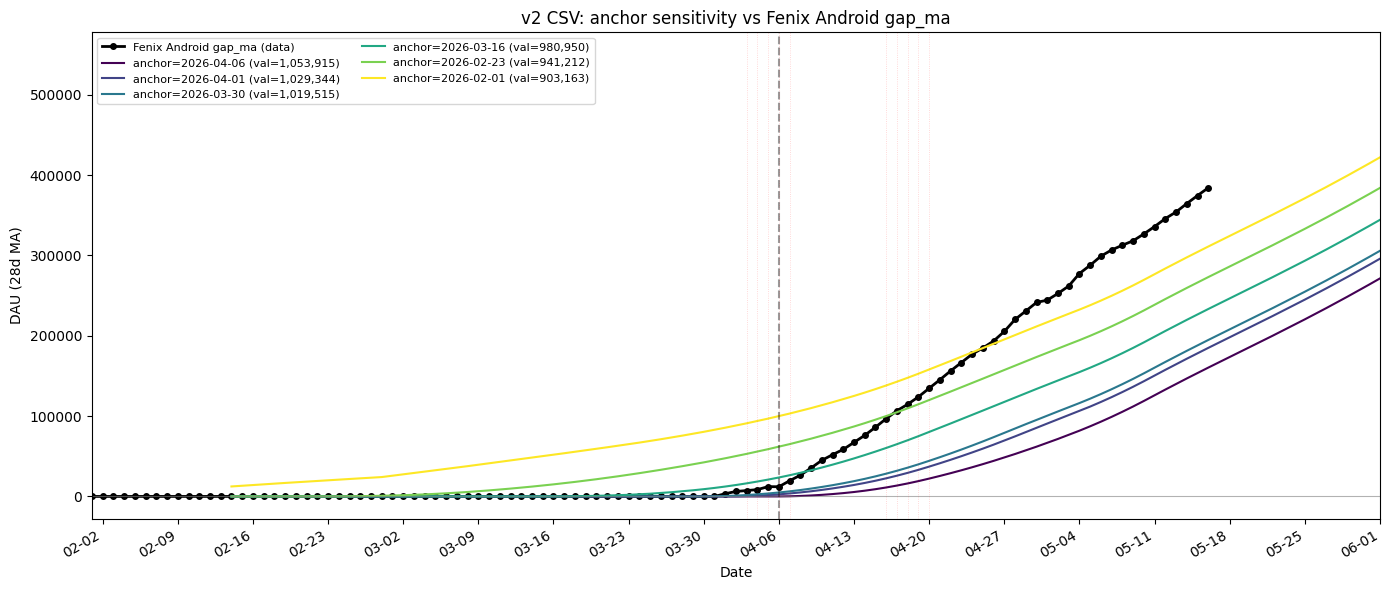


Validation A statistics for each v2 candidate anchor:
    anchor anchor_value lift_ma_mean_post fenix_resid_mean fenix_resid_rmse
2026-04-06    1,053,915           +65,691         -152,452         +164,809
2026-04-01    1,029,344           +84,791         -133,353         +144,536
2026-03-30    1,019,515           +93,045         -125,099         +136,062
2026-03-16      980,950          +128,576          -89,568         +101,958
2026-02-23      941,212          +168,275          -49,869          +69,665
2026-02-01      903,163          +206,325          -11,819          +50,060

Empirical Fenix gap MA post-launch mean (target):     +218,144

Best by RMSE:        anchor=2026-02-01  resid_mean=-11,819  rmse=+50,060
Best by |resid_mean|: anchor=2026-02-01  resid_mean=-11,819  rmse=+50,060


In [3]:
# [anchor-sensitivity-results]
# Plot all candidate lift_ma curves against the Fenix gap_ma. Report residual stats.

fig, ax = plt.subplots(figsize=(14, 6))

cmap = plt.get_cmap('viridis')
n = len(candidate_anchors)

ax.plot(fenix_gap_ma.index, fenix_gap_ma.values, 'o-', linewidth=2, markersize=4,
        color='black', label='Fenix Android gap_ma (data)')

stats_rows = []
for i, anchor in enumerate(candidate_anchors):
    anchor_value, lift_daily, lift_ma = build_lift_series(anchor)
    color = cmap(i / max(n - 1, 1))
    label = f'anchor={anchor.date()} (val={anchor_value:,.0f})'
    ax.plot(lift_ma.index, lift_ma.values, '-', linewidth=1.5, color=color, label=label)

    compare_ix = pd.date_range(CAMPAIGN_LAUNCH, LAST_HISTORICAL_DATE, freq='D').difference(EASTER_MASK_DATES)
    compare_ix = compare_ix.intersection(lift_ma.index).intersection(fenix_gap_ma.index)
    valid = lift_ma.reindex(compare_ix).notna() & fenix_gap_ma.reindex(compare_ix).notna()
    compare_ix = compare_ix[valid]

    lift_mean = lift_ma.reindex(compare_ix).mean()
    fenix_resid = (lift_ma.reindex(compare_ix) - fenix_gap_ma.reindex(compare_ix))
    stats_rows.append({
        'anchor': str(anchor.date()),
        'anchor_value': anchor_value,
        'lift_ma_mean_post': lift_mean,
        'fenix_resid_mean': fenix_resid.mean(),
        'fenix_resid_rmse': np.sqrt((fenix_resid ** 2).mean()),
    })

ax.axhline(0, color='grey', linewidth=0.8, alpha=0.6)
ax.axvline(CAMPAIGN_LAUNCH, color='black', linestyle='--', alpha=0.4)
for d in EASTER_MASK_DATES:
    ax.axvline(d, color='red', linestyle=':', linewidth=0.6, alpha=0.2)
ax.set_title('v2 CSV: anchor sensitivity vs Fenix Android gap_ma')
ax.set_ylabel('DAU (28d MA)')
ax.set_xlabel('Date')
ax.set_xlim(pd.Timestamp('2026-02-01'), pd.Timestamp('2026-06-01'))
ax.legend(fontsize=8, loc='upper left', ncol=2)
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=mdates.MO))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m-%d'))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

stats_df = pd.DataFrame(stats_rows)
print('\nValidation A statistics for each v2 candidate anchor:')
print(stats_df.to_string(index=False,
                         formatters={'anchor_value': '{:>10,.0f}'.format,
                                     'lift_ma_mean_post': '{:>+12,.0f}'.format,
                                     'fenix_resid_mean': '{:>+12,.0f}'.format,
                                     'fenix_resid_rmse': '{:>+12,.0f}'.format}))
print()
print(f'Empirical Fenix gap MA post-launch mean (target): {fenix_gap_ma.reindex(post_ix).mean():>+12,.0f}')
print()
best_by_rmse = stats_df.loc[stats_df['fenix_resid_rmse'].idxmin()]
best_by_mean = stats_df.loc[stats_df['fenix_resid_mean'].abs().idxmin()]
print(f'Best by RMSE:        anchor={best_by_rmse["anchor"]}  '
      f'resid_mean={best_by_rmse["fenix_resid_mean"]:+,.0f}  '
      f'rmse={best_by_rmse["fenix_resid_rmse"]:+,.0f}')
print(f'Best by |resid_mean|: anchor={best_by_mean["anchor"]}  '
      f'resid_mean={best_by_mean["fenix_resid_mean"]:+,.0f}  '
      f'rmse={best_by_mean["fenix_resid_rmse"]:+,.0f}')


## Synthesis

The table above shows the v2 CSV's lift-MA mean vs the empirical Fenix gap mean for each candidate anchor.

Key observations:
- **CSV-only models cannot perfectly fit the early-launch ramp** because the empirical gap grew very quickly post-launch (mean +218k MA28 over 34 days) while v2's CSV gives a smoother weekly cadence.
- **Earlier anchors produce larger lift values** (and so larger means) because they accumulate more of the CSV's pre-launch growth. An anchor before the campaign launch is conceptually wrong — pre-launch CSV growth is *not* attributable to the campaign — but the closer the residual gets to zero, the more "wrong" the conceptual baseline.
- The **anchor with the best fit metric is not necessarily the right model**. The v1 work concluded that the empirical gap simply moves *faster* than any CSV-anchored linear interpolation, which motivated the hybrid (next notebook).

We'll carry the best-anchor result forward into the hybrid build only as a sanity-check overlay — the hybrid replaces the historical portion with raw daily gap, so the anchor choice is moot for that period and only affects the forward stitch's anchor value.
